# Skillbox Final Project: Credit Risk Management Model

## Project Overview

This repository contains the final project completed as part of the Skillbox Machine Learning Engineer course.

**Task:** binary classification of the target variable `flag`.

### Dataset Specifics

A key characteristic of the dataset is that a single application (`id`) corresponds to multiple credit history records.

Therefore, the most important stage of the project is aggregating credit history data into application-level features suitable for machine learning models.

## Workflow

The notebook contains a complete end-to-end pipeline:

* Data loading
* Feature engineering and aggregation
* Model training and evaluation:

  * Logistic Regression
  * Decision Tree
  * Random Forest
  * CatBoost
* Model performance comparison
* Random Forest feature importance analysis
* Top-N feature selection validation

## Reliability and Resource Optimization

To improve stability and reduce memory consumption, the notebook uses a checkpoint-based workflow.

The following artifacts are saved during execution:

* Feature datasets:

  * `features_v1.parquet`
  * ...
  * `features_v8.parquet`
* Intermediate `part` files generated from each source dataset (`train_data_*.pq`)
* Model evaluation results stored in JSON format
* Consolidated experiment summary table: `experiments_summary.csv`
* Top-N feature selection results

If execution is interrupted or memory limits are reached, rerunning the notebook does not restart the entire pipeline. Previously generated artifacts are loaded from disk, and only missing steps are executed.

## Memory Management

Feature versions (`v1`–`v8`) are not stored in memory simultaneously.

For each iteration:

1. Features are generated.
2. Saved to a Parquet file.
3. Removed from memory.

During model training, feature datasets are also loaded one version at a time, significantly reducing RAM usage and enabling experimentation with multiple feature engineering approaches on large datasets.


## 1. Imports, Paths, and Configuration

In [1]:
from pathlib import Path
from datetime import datetime
import gc
import json
import warnings

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

# Root directory of the project.
DATA_PATH = Path(".")
DATA_PATH_TRAIN_DATA = DATA_PATH / "train_data"
TARGET_PATH = DATA_PATH / "train_target.csv"

# Directory for all intermediate artifacts.
# If the notebook crashes or runs out of memory,
# the next execution will resume from the saved files
# instead of starting from scratch.
CHECKPOINT_DIR = DATA_PATH / "checkpoints"
FEATURES_DIR = CHECKPOINT_DIR / "features"
FEATURE_PARTS_DIR = CHECKPOINT_DIR / "feature_parts"
RESULTS_DIR = CHECKPOINT_DIR / "results"
IMPORTANCES_DIR = CHECKPOINT_DIR / "importances"
TOPN_DIR = CHECKPOINT_DIR / "topn"

for directory in [
    CHECKPOINT_DIR,
    FEATURES_DIR,
    FEATURE_PARTS_DIR,
    RESULTS_DIR,
    IMPORTANCES_DIR,
    TOPN_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

# To force feature regeneration or model retraining,
# set the corresponding flag to True.
FORCE_REBUILD_FEATURES = False
FORCE_RETRAIN_MODELS = False
FORCE_RETRAIN_TOPN = False

FEATURE_VERSIONS = ["v1", "v2", "v3", "v4", "v5", "v6", "v7", "v8"]

# Paths to the final feature datasets.
FEATURE_PATHS = {
    version: FEATURES_DIR / f"features_{version}.parquet"
    for version in FEATURE_VERSIONS
}

EXPERIMENTS_SUMMARY_PATH = RESULTS_DIR / "experiments_summary.csv"

## 2. Input File Validation and Target Loading

### Logic

* If the final feature datasets are already available in `checkpoints/features`, the original `train_data_*.pq` files are not required for feature generation.
* If any feature dataset is missing, the source Parquet files are required to rebuild the corresponding features.
* The `target` dataset is only needed for model training. If all model results have already been saved and retraining is disabled, the notebook can load and display the existing experiment results without performing a new training run.

In [2]:
# Check which feature dataset versions are already available.
existing_feature_versions = [
    version
    for version, path in FEATURE_PATHS.items()
    if path.exists()
]

missing_feature_versions = [
    version
    for version in FEATURE_VERSIONS
    if version not in existing_feature_versions
]

print("Available feature dataset versions:", existing_feature_versions)
print("Missing feature dataset versions:", missing_feature_versions)

# Source Parquet files are required only when missing feature datasets
# need to be generated or when forced recomputation is enabled.
need_raw_train_data = bool(missing_feature_versions) or FORCE_REBUILD_FEATURES

if need_raw_train_data:
    files = sorted(DATA_PATH_TRAIN_DATA.glob("train_data_*.pq"))

    print("\nСтроим признаки, проверяем исходные train_data_*.pq")

    if len(files) > 0:
        print("First file:", files[0])
        print("Last file:", files[-1])
    else:
        raise FileNotFoundError(
            "No Parquet files were found in the train_data directory. "
            "They are required because some feature datasets have not yet been generated."
        )
else:
    # Raw source data is neither loaded nor required.
    files = []
    print("\nAll feature datasets are already available. The original train_data_*.pq files are not needed at this stage.")

# The target dataset is required for model training.
# If the target file is missing but all model results have already been saved,
# the existing experiments_summary.csv can still be reviewed without retraining.
if TARGET_PATH.exists():
    target = pd.read_csv(TARGET_PATH)

    print("\nTarget shape:", target.shape)
    print("Unique IDs:", target["id"].nunique())
    print("Duplicate IDs:", target["id"].duplicated().sum())

    display(target.head())
else:
    target = None
    print("\ntrain_target.csv was not found.")
    print(
        "Model training is not possible, but the saved results "
        "from checkpoints/results can still be reviewed."
    )

Available feature dataset versions: ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8']
Missing feature dataset versions: []

All feature datasets are already available. The original train_data_*.pq files are not needed at this stage.

Target shape: (3000000, 2)
Unique IDs: 3000000
Duplicate IDs: 0


,id,flag
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


## 3. Helper Functions

In [3]:
def clear_memory():
    # Force memory cleanup between heavy processing steps.
    gc.collect()
    print("Memory cleared")


def save_json(data, path):
    # Save a dictionary to a JSON file.
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=2)


def load_json(path):
    # Load a dictionary from a JSON file.
    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def read_experiments_summary():
    # Load the consolidated experiment summary table if it already exists.
    if EXPERIMENTS_SUMMARY_PATH.exists():
        return (
            pd.read_csv(EXPERIMENTS_SUMMARY_PATH)
            .sort_values("test_roc_auc", ascending=False)
            .reset_index(drop=True)
        )

    return pd.DataFrame(
        columns=[
            "features_version",
            "model",
            "train_roc_auc",
            "test_roc_auc",
            "gap",
            "n_features",
            "created_at",
        ]
    )


def upsert_experiment_summary(row):
    # Add or update a row in experiments_summary.csv.
    #
    # This is the main checkpoint for the experiment results table.
    # After each completed training experiment, the result is immediately saved to disk.
    # Therefore, if the notebook crashes, already computed metrics are not lost.
    row = dict(row)
    row["created_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    summary = read_experiments_summary()

    if len(summary) > 0:
        mask = (
            (summary["features_version"] == row["features_version"])
            & (summary["model"] == row["model"])
        )
        summary = summary.loc[~mask].copy()

    summary = pd.concat([summary, pd.DataFrame([row])], ignore_index=True)
    summary = (
        summary
        .sort_values("test_roc_auc", ascending=False)
        .reset_index(drop=True)
    )

    EXPERIMENTS_SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
    summary.to_csv(EXPERIMENTS_SUMMARY_PATH, index=False)

    return summary


def result_path(version, model_name):
    # Path to the JSON file with model metrics.
    safe_model = model_name.lower().replace(" ", "_")
    return RESULTS_DIR / f"{version}__{safe_model}.json"


def importance_path(version):
    # Path to the Parquet file with Random Forest feature importances.
    return IMPORTANCES_DIR / f"{version}__random_forest_importance.parquet"


def save_model_result(version, model_name, result):
    # Save model metrics to JSON and update experiments_summary.csv.
    #
    # The model object, X_train, and X_test are not saved to avoid unnecessary
    # memory and disk usage.
    # Only the information required for analysis and project defense is saved:
    # - train ROC-AUC;
    # - test ROC-AUC;
    # - gap;
    # - feature list;
    # - number of features.
    payload = {
        "features_version": version,
        "model": model_name,
        "train_auc": float(result["train_auc"]),
        "test_auc": float(result["test_auc"]),
        "gap": float(result["train_auc"] - result["test_auc"]),
        "n_features": int(len(result["feature_names"])),
        "feature_names": list(result["feature_names"]),
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }

    save_json(payload, result_path(version, model_name))

    upsert_experiment_summary({
        "features_version": version,
        "model": model_name,
        "train_roc_auc": payload["train_auc"],
        "test_roc_auc": payload["test_auc"],
        "gap": payload["gap"],
        "n_features": payload["n_features"],
    })

    return payload


def experiment_row_from_json(version, model_name):
    # Return an experiment result row from a JSON checkpoint.
    item = load_json(result_path(version, model_name))

    return {
        "features_version": item["features_version"],
        "model": item["model"],
        "train_roc_auc": item["train_auc"],
        "test_roc_auc": item["test_auc"],
        "gap": item["gap"],
        "n_features": item["n_features"],
    }


def load_all_experiment_results():
    # Load all saved model metrics from checkpoints/results.
    #
    # If experiments_summary.csv exists, it is used directly.
    # Otherwise, the summary table is reconstructed from individual JSON files.
    if EXPERIMENTS_SUMMARY_PATH.exists():
        return read_experiments_summary()

    rows = []

    for path in sorted(RESULTS_DIR.glob("*.json")):
        item = load_json(path)
        rows.append({
            "features_version": item["features_version"],
            "model": item["model"],
            "train_roc_auc": item["train_auc"],
            "test_roc_auc": item["test_auc"],
            "gap": item["gap"],
            "n_features": item["n_features"],
            "created_at": item.get("created_at"),
        })

    if len(rows) == 0:
        return read_experiments_summary()

    summary = (
        pd.DataFrame(rows)
        .sort_values("test_roc_auc", ascending=False)
        .reset_index(drop=True)
    )

    summary.to_csv(EXPERIMENTS_SUMMARY_PATH, index=False)
    return summary


def validate_features(features, name="features"):
    # Basic validation checks for a feature table.
    print(f"{name} shape:", features.shape)
    print(f"{name} unique IDs:", features["id"].nunique())
    print(f"{name} duplicated IDs:", features["id"].duplicated().sum())

    missing = features.isna().mean().sort_values(ascending=False)

    print("\nTop missing values:")
    display(missing.head(15).to_frame("missing_share"))

    return missing


def build_features_all_files(
    build_func,
    output_path,
    version_name,
    force_rebuild=FORCE_REBUILD_FEATURES,
):
    # Build features across all Parquet files with per-file checkpoints.
    #
    # On rerun:
    # - if the final file already exists, it is loaded directly;
    # - if some part files already exist, they are not recomputed;
    # - only one source Parquet file is kept in memory at a time.
    output_path = Path(output_path)
    part_dir = FEATURE_PARTS_DIR / version_name
    part_dir.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and not force_rebuild:
        print("Final file already exists, loading:", output_path)
        features = pd.read_parquet(output_path)
        print("Features shape:", features.shape)
        print("Unique IDs:", features["id"].nunique())
        return features

    if len(files) == 0:
        raise RuntimeError(
            f"Cannot build {version_name}: the list of source train_data_*.pq files is empty. "
            "Check DATA_PATH_TRAIN_DATA or make sure the final feature Parquet file exists."
        )

    part_paths = []

    for file in files:
        part_path = part_dir / f"{file.stem}__{version_name}.parquet"
        part_paths.append(part_path)

        if part_path.exists() and not force_rebuild:
            print("Part file already exists, skipping:", part_path.name)
            continue

        print(f"Processing {version_name}: {file.name}")
        df = pd.read_parquet(file)

        part = build_func(df)
        part.to_parquet(part_path, index=False)

        print("Saved part:", part_path)

        del df, part
        clear_memory()

    print(f"\nMerging final features for {version_name} from part files")

    features_parts = []
    for part_path in part_paths:
        features_parts.append(pd.read_parquet(part_path))

    features = pd.concat(features_parts, ignore_index=True)

    # As a safety check, merge duplicate IDs.
    # If the same ID appears in multiple train_data files, aggregate using max.
    if features["id"].duplicated().sum() > 0:
        print("Duplicate IDs found across part files. Merging with max aggregation.")
        features = features.groupby("id", as_index=False).max()

    features.to_parquet(output_path, index=False)

    print("Saved final features:", output_path)
    print("Features shape:", features.shape)
    print("Unique IDs:", features["id"].nunique())

    del features_parts

    return features


def prepare_model_data(features, random_state=RANDOM_STATE):
    # Merge features with the target and perform train/test split.
    #
    # - NaN values are filled with zeros after aggregation;
    # - features are converted to float32 to reduce memory usage.
    if target is None:
        raise RuntimeError(
            "train_target.csv has not been loaded. "
            "The target dataset is required for model training."
        )
    target_like_cols = [
        col for col in features.columns
        if col == "flag" or col.startswith("flag_")
    ]

    if target_like_cols:
        print("Removed target-like columns from features:", target_like_cols)
        features = features.drop(columns=target_like_cols)
        
    df_model = features.merge(
        target[["id", "flag"]],
        on="id",
        how="inner",
    ).fillna(0)

    X = df_model.drop(columns=["id", "flag"]).astype("float32")
    y = df_model["flag"].astype("int8")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=random_state,
        stratify=y,
    )

    del df_model, X, y
    gc.collect()

    return X_train, X_test, y_train, y_test


def add_experiment_result(experiments, version, model_name, result):
    # Add an experiment result to the local list and return a sorted table.
    experiments.append({
        "features_version": version,
        "model": model_name,
        "train_roc_auc": result["train_auc"],
        "test_roc_auc": result["test_auc"],
        "gap": result["train_auc"] - result["test_auc"],
        "n_features": len(result["feature_names"]),
    })

    return pd.DataFrame(experiments).sort_values("test_roc_auc", ascending=False)

## 4. Model Training Functions

In [4]:
def test_features_lr(features, random_state=RANDOM_STATE):
    # Logistic Regression is a linear baseline model.
    #
    # Feature scaling is required because Logistic Regression is sensitive
    # to feature scale.
    #
    # To reduce memory usage, the function returns only metrics and the feature list,
    # not X_train/X_test.
    X_train, X_test, y_train, y_test = prepare_model_data(features, random_state)
    feature_names = list(X_train.columns)

    lr_pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ))
    ])

    lr_pipeline.fit(X_train, y_train)

    train_pred = lr_pipeline.predict_proba(X_train)[:, 1]
    test_pred = lr_pipeline.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)

    print(f"Train LR ROC-AUC: {train_auc:.6f}")
    print(f"Test  LR ROC-AUC: {test_auc:.6f}")

    del X_train, X_test, y_train, y_test
    del train_pred, test_pred, lr_pipeline
    gc.collect()

    return {
        "feature_names": feature_names,
        "train_auc": train_auc,
        "test_auc": test_auc,
    }


def test_features_dt(
    features,
    max_depth=6,
    min_samples_leaf=100,
    random_state=RANDOM_STATE,
):
    # Decision Tree is a simple nonlinear model.
    X_train, X_test, y_train, y_test = prepare_model_data(features, random_state)
    feature_names = list(X_train.columns)

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",
        random_state=random_state,
    )

    model.fit(X_train, y_train)

    train_pred = model.predict_proba(X_train)[:, 1]
    test_pred = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)

    print(f"Train DT ROC-AUC: {train_auc:.6f}")
    print(f"Test  DT ROC-AUC: {test_auc:.6f}")

    del X_train, X_test, y_train, y_test
    del train_pred, test_pred, model
    gc.collect()

    return {
        "feature_names": feature_names,
        "train_auc": train_auc,
        "test_auc": test_auc,
    }


def test_features_rf(
    features,
    n_estimators=500,
    max_depth=18,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
):
    # Random Forest is one of the key models in this project.
    X_train, X_test, y_train, y_test = prepare_model_data(features, random_state)
    feature_names = list(X_train.columns)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",
        max_features="sqrt",
        random_state=random_state,
        n_jobs=-1,
    )

    model.fit(X_train, y_train)

    train_pred = model.predict_proba(X_train)[:, 1]
    test_pred = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)

    feature_importances = model.feature_importances_.copy()

    print(f"Train RF ROC-AUC: {train_auc:.6f}")
    print(f"Test  RF ROC-AUC: {test_auc:.6f}")
    print(f"Gap train-test:   {train_auc - test_auc:.6f}")

    del X_train, X_test, y_train, y_test
    del train_pred, test_pred, model
    gc.collect()

    return {
        "feature_names": feature_names,
        "feature_importances": feature_importances,
        "train_auc": train_auc,
        "test_auc": test_auc,
    }


def test_features_catboost(
    features,
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_state=RANDOM_STATE,
):
    # CatBoost is used for comparison with Random Forest.
    #
    # Feature scaling is not required.
    X_train, X_test, y_train, y_test = prepare_model_data(features, random_state)
    feature_names = list(X_train.columns)

    model = CatBoostClassifier(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=random_state,
        verbose=False,
        allow_writing_files=False,
    )

    model.fit(X_train, y_train)

    train_pred = model.predict_proba(X_train)[:, 1]
    test_pred = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)

    print(f"Train CatBoost ROC-AUC: {train_auc:.6f}")
    print(f"Test  CatBoost ROC-AUC: {test_auc:.6f}")
    print(f"Gap train-test:         {train_auc - test_auc:.6f}")

    feature_importances = model.get_feature_importance()

    del X_train, X_test, y_train, y_test
    del train_pred, test_pred, model
    gc.collect()

    return {
        "feature_names": feature_names,
        "feature_importances": feature_importances,
        "train_auc": train_auc,
        "test_auc": test_auc,
    }

## 5. Common Groups of Raw Features

In [5]:
# Monthly payment history features.
paym_cols = [f"enc_paym_{i}" for i in range(25)]

# Core numerical credit history features.
num_cols = [
    "pre_since_opened",
    "pre_since_confirmed",
    "pre_pterm",
    "pre_fterm",
    "pre_till_pclose",
    "pre_till_fclose",
    "pre_loans_credit_limit",
    "pre_loans_next_pay_summ",
    "pre_loans_outstanding",
    "pre_util",
    "pre_over2limit",
    "pre_maxover2limit",
]

# Delinquency-related features.
overdue_cols = [
    "pre_loans5",
    "pre_loans530",
    "pre_loans3060",
    "pre_loans6090",
    "pre_loans90",
]

# Encoded categorical features.
category_cols = [
    "enc_loans_credit_status",
    "enc_loans_credit_type",
    "enc_loans_account_holder_type",
    "enc_loans_account_cur",
]

# Binary indicators of zero values.
binary_cols = [
    "is_zero_loans5",
    "is_zero_loans530",
    "is_zero_loans3060",
    "is_zero_loans6090",
    "is_zero_loans90",
    "is_zero_util",
    "is_zero_over2limit",
    "is_zero_maxover2limit",
]

## 6. Feature Engineering (v1–v8)

### v1: Basic Credit History Aggregations

In [6]:
def build_features_v1(df: pd.DataFrame) -> pd.DataFrame:
    # v1: basic aggregations of credit history records.
    #
    # Main idea:
    # - credit history size
    # - mean and maximum values of numerical features
    # - maximum delinquency indicators
    # - simple aggregations of encoded categorical features
    agg_dict = {"rn": ["count"]}

    for col in num_cols:
        if col in df.columns:
            agg_dict[col] = ["mean", "max"]

    for col in overdue_cols:
        if col in df.columns:
            agg_dict[col] = ["max"]

    for col in category_cols:
        if col in df.columns:
            agg_dict[col] = ["max", "nunique"]

    for col in ["pclose_flag", "fclose_flag"]:
        if col in df.columns:
            agg_dict[col] = ["sum", "mean"]

    features = df.groupby("id").agg(agg_dict)
    features.columns = [f"{col}_{stat}" for col, stat in features.columns]

    return features.reset_index()

### v2: Alternative Aggregations and Last Credit Features

In [7]:
def build_features_v2(df: pd.DataFrame) -> pd.DataFrame:
    # v2: additional statistics for key numerical features + last credit record.
    #
    # Main idea:
    # - add min/std aggregations
    # - separately store features from the client's latest credit history record
    local_num_cols = [
        "pre_util",
        "pre_over2limit",
        "pre_maxover2limit",
        "pre_loans_credit_limit",
        "pre_loans_outstanding",
    ]

    local_cat_cols = [
        "enc_loans_credit_status",
        "enc_loans_credit_type",
    ]

    last_cols = [
        "pre_util",
        "pre_over2limit",
        "pre_maxover2limit",
        "enc_loans_credit_status",
        "enc_loans_credit_type",
        "pclose_flag",
        "fclose_flag",
    ]

    local_num_cols = [col for col in local_num_cols if col in df.columns]
    local_cat_cols = [col for col in local_cat_cols if col in df.columns]
    last_cols = [col for col in last_cols if col in df.columns]

    agg_dict = {"rn": ["count"]}

    for col in local_num_cols:
        agg_dict[col] = ["mean", "max", "min", "std"]

    for col in local_cat_cols:
        agg_dict[col] = ["max", "nunique"]

    for col in ["pclose_flag", "fclose_flag"]:
        if col in df.columns:
            agg_dict[col] = ["sum", "mean"]

    features = df.groupby("id").agg(agg_dict)
    features.columns = [f"{col}_{stat}" for col, stat in features.columns]
    features = features.reset_index()

    # Latest client record. rn is used as the record order within credit history.
    idx = df.groupby("id")["rn"].idxmax()
    last_df = df.loc[idx, ["id"] + last_cols].copy()
    last_df = last_df.rename(columns={col: f"last_{col}" for col in last_cols})

    features = features.merge(last_df, on="id", how="left")

    return features.fillna(0)

### v3: Adding Payment History Features `enc_paym_0`–`enc_paym_24`

In [8]:
def build_features_v3(df: pd.DataFrame) -> pd.DataFrame:
    # v3: v1 + aggregations for each monthly payment history feature.
    #
    # Main idea:
    # - `enc_paym_0` is closer to the current moment
    # - `enc_paym_24` is further in the past
    # - for each month, calculate mean/max across all client credits
    agg_dict = {"rn": ["count"]}

    for col in num_cols:
        if col in df.columns:
            agg_dict[col] = ["mean", "max"]

    for col in overdue_cols:
        if col in df.columns:
            agg_dict[col] = ["max"]

    for col in category_cols:
        if col in df.columns:
            agg_dict[col] = ["max", "nunique"]

    for col in paym_cols:
        if col in df.columns:
            agg_dict[col] = ["mean", "max"]

    for col in ["pclose_flag", "fclose_flag"]:
        if col in df.columns:
            agg_dict[col] = ["sum", "mean"]

    features = df.groupby("id").agg(agg_dict)
    features.columns = [f"{col}_{stat}" for col, stat in features.columns]

    return features.reset_index()

### v4: Adding Binary Zero-Value Indicators

In [9]:
def build_features_v4(df: pd.DataFrame) -> pd.DataFrame:
    # v4: v3 + binary zero-value indicators.
    #
    # These features are important for credit risk assessment:
    # zero delinquencies, zero utilization, and no credit limit exceedance.
    agg_dict = {"rn": ["count"]}

    for col in num_cols:
        if col in df.columns:
            agg_dict[col] = ["mean", "max"]

    for col in overdue_cols:
        if col in df.columns:
            agg_dict[col] = ["max"]

    for col in category_cols:
        if col in df.columns:
            agg_dict[col] = ["max", "nunique"]

    for col in paym_cols:
        if col in df.columns:
            agg_dict[col] = ["mean", "max"]

    for col in binary_cols:
        if col in df.columns:
            agg_dict[col] = ["mean", "sum", "max"]

    for col in ["pclose_flag", "fclose_flag"]:
        if col in df.columns:
            agg_dict[col] = ["sum", "mean"]

    features = df.groupby("id").agg(agg_dict)
    features.columns = [f"{col}_{stat}" for col, stat in features.columns]

    return features.reset_index()

### v5: Risk-Oriented Features

In [10]:
def build_features_v5(df: pd.DataFrame) -> pd.DataFrame:
    # v5: risk-oriented features.
    #
    # Main idea:
    # - credit burden
    # - share of problematic credits
    # - extreme delinquency values
    # - client's latest credit record
    # - diversity of credit types and statuses
    df = df.copy()
    df = df.sort_values(["id", "rn"])

    risk_num_cols = [
        "pre_loans_credit_limit",
        "pre_loans_outstanding",
        "pre_loans_total_overdue",
        "pre_loans_max_overdue_sum",
        "pre_loans_credit_cost_rate",
        "pre_util",
        "pre_over2limit",
        "pre_maxover2limit",
    ]
    risk_num_cols = [col for col in risk_num_cols if col in df.columns]

    agg_dict = {
        col: ["mean", "max", "min", "std", "sum"]
        for col in risk_num_cols
    }

    features = df.groupby("id").agg(agg_dict)

    if len(features.columns) > 0:
        features.columns = [f"{col}_{stat}" for col, stat in features.columns]
        features = features.reset_index()
    else:
        features = df[["id"]].drop_duplicates().copy()

    # Number of credits in the client's history.
    credit_count = (
        df.groupby("id")["rn"]
        .count()
        .reset_index(name="credit_count")
    )
    features = features.merge(credit_count, on="id", how="left")

    # Total delinquency score.
    local_overdue_cols = [col for col in overdue_cols if col in df.columns]

    if local_overdue_cols:
        df["overdue_score"] = df[local_overdue_cols].sum(axis=1)

        overdue_features = (
            df.groupby("id")["overdue_score"]
            .agg(["mean", "max", "sum"])
            .reset_index()
        )
        overdue_features.columns = [
            "id",
            "overdue_score_mean",
            "overdue_score_max",
            "overdue_score_sum",
        ]

        features = features.merge(overdue_features, on="id", how="left")

        df["has_overdue"] = (df["overdue_score"] > 0).astype(int)

        overdue_ratio = (
            df.groupby("id")["has_overdue"]
            .mean()
            .reset_index(name="overdue_loans_ratio")
        )

        features = features.merge(overdue_ratio, on="id", how="left")

    # Mean values of binary indicators.
    local_binary_cols = [col for col in binary_cols if col in df.columns]

    if local_binary_cols:
        zero_features = (
            df.groupby("id")[local_binary_cols]
            .mean()
            .reset_index()
        )

        zero_features = zero_features.rename(
            columns={col: f"{col}_mean" for col in local_binary_cols}
        )

        features = features.merge(zero_features, on="id", how="left")

    # Client's latest credit record.
    last_cols = [
        "pre_loans_credit_limit",
        "pre_loans_outstanding",
        "pre_loans_total_overdue",
        "pre_loans_max_overdue_sum",
        "pre_loans_credit_cost_rate",
        "pre_util",
        "pre_over2limit",
        "pre_maxover2limit",
        "enc_loans_credit_status",
        "enc_loans_credit_type",
        "pclose_flag",
        "fclose_flag",
    ]
    last_cols = [col for col in last_cols if col in df.columns]

    if last_cols:
        last_credit = df.groupby("id").tail(1)[["id"] + last_cols].copy()
        last_credit = last_credit.rename(
            columns={col: f"last_{col}" for col in last_cols}
        )
        features = features.merge(last_credit, on="id", how="left")

    # Number of unique credit types.
    if "enc_loans_credit_type" in df.columns:
        credit_type_count = (
            df.groupby("id")["enc_loans_credit_type"]
            .nunique()
            .reset_index(name="unique_credit_type_count")
        )
        features = features.merge(credit_type_count, on="id", how="left")

    # Number of unique credit statuses.
    if "enc_loans_credit_status" in df.columns:
        credit_status_count = (
            df.groupby("id")["enc_loans_credit_status"]
            .nunique()
            .reset_index(name="unique_credit_status_count")
        )
        features = features.merge(credit_status_count, on="id", how="left")

    return features.fillna(0)

### v6: Aggregations Across the Entire Payment Matrix

In [11]:
def build_features_v6(df: pd.DataFrame) -> pd.DataFrame:
    # v6: v4 + aggregations across the entire payment matrix.
    #
    # Main idea:
    # for each credit record, calculate characteristics of the full
    # `enc_paym_0...enc_paym_24` sequence, then aggregate them to the client level.
    features = build_features_v4(df)

    pay_cols = [col for col in paym_cols if col in df.columns]
    agg_dict = df[["id"] + pay_cols].copy()

    agg_dict["pay_mean"] = agg_dict[pay_cols].mean(axis=1)
    agg_dict["pay_std"] = agg_dict[pay_cols].std(axis=1)
    agg_dict["pay_min"] = agg_dict[pay_cols].min(axis=1)
    agg_dict["pay_max"] = agg_dict[pay_cols].max(axis=1)
    agg_dict["pay_range"] = agg_dict["pay_max"] - agg_dict["pay_min"]
    agg_dict["pay_nunique"] = agg_dict[pay_cols].nunique(axis=1)
    agg_dict["pay_nonzero_ratio"] = (agg_dict[pay_cols] != 0).mean(axis=1)
    agg_dict["pay_negative_ratio"] = (agg_dict[pay_cols] < 0).mean(axis=1)
    agg_dict["pay_bad_count"] = (agg_dict[pay_cols] > 0).sum(axis=1)

    pay_features = (
        agg_dict.groupby("id")
        .agg({
            "pay_mean": ["mean", "max", "std"],
            "pay_std": ["mean", "max"],
            "pay_range": ["mean", "max"],
            "pay_nunique": ["mean", "max"],
            "pay_nonzero_ratio": ["mean", "max"],
            "pay_negative_ratio": ["mean", "max"],
            "pay_bad_count": ["mean", "max"],
        })
    )

    pay_features.columns = [f"{col}_{stat}" for col, stat in pay_features.columns]
    pay_features = pay_features.reset_index()

    features = features.merge(pay_features, on="id", how="left")

    return features.fillna(0)

### v7: Time Windows and Payment History Trends

In [12]:
def build_features_v7(df: pd.DataFrame) -> pd.DataFrame:
    # v7: v6 + payment time windows.
    #
    # Main idea:
    # not only the client's average behavior across the entire history matters,
    # but also how their behavior has changed in recent months.
    features = build_features_v6(df)

    pay_cols = [col for col in paym_cols if col in df.columns]
    agg_dict = df[["id"] + pay_cols].copy()

    recent3 = [f"enc_paym_{i}" for i in range(3) if f"enc_paym_{i}" in agg_dict.columns]
    recent6 = [f"enc_paym_{i}" for i in range(6) if f"enc_paym_{i}" in agg_dict.columns]
    recent12 = [f"enc_paym_{i}" for i in range(12) if f"enc_paym_{i}" in agg_dict.columns]

    old6 = [f"enc_paym_{i}" for i in range(18, 25) if f"enc_paym_{i}" in agg_dict.columns]
    old12 = [f"enc_paym_{i}" for i in range(13, 25) if f"enc_paym_{i}" in agg_dict.columns]

    # Mean payment status by time window.
    agg_dict["pay_recent3_mean"] = agg_dict[recent3].mean(axis=1)
    agg_dict["pay_recent6_mean"] = agg_dict[recent6].mean(axis=1)
    agg_dict["pay_recent12_mean"] = agg_dict[recent12].mean(axis=1)

    agg_dict["pay_old6_mean"] = agg_dict[old6].mean(axis=1)
    agg_dict["pay_old12_mean"] = agg_dict[old12].mean(axis=1)

    # Maximum delinquency by time window.
    agg_dict["pay_recent3_max"] = agg_dict[recent3].max(axis=1)
    agg_dict["pay_recent6_max"] = agg_dict[recent6].max(axis=1)
    agg_dict["pay_recent12_max"] = agg_dict[recent12].max(axis=1)

    agg_dict["pay_old6_max"] = agg_dict[old6].max(axis=1)
    agg_dict["pay_old12_max"] = agg_dict[old12].max(axis=1)

    # Share of bad payments. A bad payment is defined as enc_paym > 0.
    agg_dict["pay_recent3_bad_ratio"] = (agg_dict[recent3] > 0).mean(axis=1)
    agg_dict["pay_recent6_bad_ratio"] = (agg_dict[recent6] > 0).mean(axis=1)
    agg_dict["pay_recent12_bad_ratio"] = (agg_dict[recent12] > 0).mean(axis=1)

    agg_dict["pay_old6_bad_ratio"] = (agg_dict[old6] > 0).mean(axis=1)
    agg_dict["pay_old12_bad_ratio"] = (agg_dict[old12] > 0).mean(axis=1)

    # Trends: a positive value means that the recent period is worse than the old period.
    agg_dict["pay_trend6_mean"] = agg_dict["pay_recent6_mean"] - agg_dict["pay_old6_mean"]
    agg_dict["pay_trend12_mean"] = agg_dict["pay_recent12_mean"] - agg_dict["pay_old12_mean"]

    agg_dict["pay_trend6_bad_ratio"] = (
        agg_dict["pay_recent6_bad_ratio"] - agg_dict["pay_old6_bad_ratio"]
    )
    agg_dict["pay_trend12_bad_ratio"] = (
        agg_dict["pay_recent12_bad_ratio"] - agg_dict["pay_old12_bad_ratio"]
    )

    v7_cols = [
        "pay_recent3_mean",
        "pay_recent6_mean",
        "pay_recent12_mean",
        "pay_old6_mean",
        "pay_old12_mean",
        "pay_recent3_max",
        "pay_recent6_max",
        "pay_recent12_max",
        "pay_old6_max",
        "pay_old12_max",
        "pay_recent3_bad_ratio",
        "pay_recent6_bad_ratio",
        "pay_recent12_bad_ratio",
        "pay_old6_bad_ratio",
        "pay_old12_bad_ratio",
        "pay_trend6_mean",
        "pay_trend12_mean",
        "pay_trend6_bad_ratio",
        "pay_trend12_bad_ratio",
    ]

    # A client may have multiple credits, so time-window features
    # are aggregated to the application ID level.
    pay_window_features = agg_dict.groupby("id")[v7_cols].agg(["mean", "max", "std"])
    pay_window_features.columns = [
        f"{col}_{stat}"
        for col, stat in pay_window_features.columns
    ]
    pay_window_features = pay_window_features.reset_index()

    features = features.merge(pay_window_features, on="id", how="left")

    return features.fillna(0)

### v8: Last Credit Features and Comparison with Historical Behavior

v8 hypothesis:

- The client's most recent credits may reflect current risk better than average aggregates across the entire history.
- A sharp deterioration of the latest credit compared to the client's usual behavior may be an important default risk signal.
- Count/ratio features for problematic credits help CatBoost distinguish clients with rare random delinquencies from clients with systematic credit issues.

Important: all features are built only from credit history data, without using `flag`, so there is no target leakage here.

In [13]:
def safe_divide(a, b, eps=1e-6):
    # Safe division for ratio features.
    return a / (np.abs(b) + eps)


def build_features_v8(df: pd.DataFrame) -> pd.DataFrame:
    # v8: v7 + last loan features + last-vs-history features.
    #
    # Main idea:
    # average aggregations may hide deterioration in client behavior.
    # Therefore, we separately extract characteristics of the client's latest loan
    # and compare them with the entire previous history.
    #
    # Last loan selection logic:
    # - if the rn column exists, use the row with the maximum rn within each id;
    # - otherwise, use the client's last row in the original order.
    features = build_features_v7(df)

    # Key fields that may reflect current debt burden,
    # credit limit utilization, and delinquency behavior.
    # Only columns that actually exist in the dataset are used.
    last_candidate_cols = [
        "pre_since_opened",
        "pre_since_confirmed",
        "pre_pterm",
        "pre_fterm",
        "pre_till_pclose",
        "pre_till_fclose",
        "pre_loans_credit_limit",
        "pre_loans_next_pay_summ",
        "pre_loans_outstanding",
        "pre_util",
        "pre_over2limit",
        "pre_maxover2limit",
        "pre_loans_total_overdue",
        "pre_loans_max_overdue_sum",
        "pre_loans5",
        "pre_loans530",
        "pre_loans3060",
        "pre_loans6090",
        "pre_loans90",
        "enc_loans_credit_status",
        "enc_loans_credit_type",
        "enc_loans_account_holder_type",
        "enc_loans_account_cur",
    ]

    last_value_cols = [col for col in last_candidate_cols if col in df.columns]

    # Add compact features based on the payment matrix of each individual loan.
    pay_cols = [col for col in paym_cols if col in df.columns]
    tmp_cols = ["id"] + (["rn"] if "rn" in df.columns else []) + last_value_cols + pay_cols
    agg_dict = df[tmp_cols].copy()

    if len(pay_cols) > 0:
        agg_dict["loan_pay_mean"] = agg_dict[pay_cols].mean(axis=1)
        agg_dict["loan_pay_max"] = agg_dict[pay_cols].max(axis=1)
        agg_dict["loan_pay_bad_ratio"] = (agg_dict[pay_cols] > 0).mean(axis=1)
        agg_dict["loan_pay_zero_ratio"] = (agg_dict[pay_cols] == 0).mean(axis=1)

        recent_pay_cols = [
            f"enc_paym_{i}"
            for i in range(6)
            if f"enc_paym_{i}" in agg_dict.columns
        ]
        old_pay_cols = [
            f"enc_paym_{i}"
            for i in range(13, 25)
            if f"enc_paym_{i}" in agg_dict.columns
        ]

        if len(recent_pay_cols) > 0:
            agg_dict["loan_pay_recent6_mean"] = agg_dict[recent_pay_cols].mean(axis=1)
            agg_dict["loan_pay_recent6_bad_ratio"] = (
                agg_dict[recent_pay_cols] > 0
            ).mean(axis=1)

        if len(old_pay_cols) > 0:
            agg_dict["loan_pay_old12_mean"] = agg_dict[old_pay_cols].mean(axis=1)
            agg_dict["loan_pay_old12_bad_ratio"] = (
                agg_dict[old_pay_cols] > 0
            ).mean(axis=1)

        if "loan_pay_recent6_mean" in agg_dict.columns and "loan_pay_old12_mean" in agg_dict.columns:
            agg_dict["loan_pay_trend_mean"] = (
                agg_dict["loan_pay_recent6_mean"] - agg_dict["loan_pay_old12_mean"]
            )

        if "loan_pay_recent6_bad_ratio" in agg_dict.columns and "loan_pay_old12_bad_ratio" in agg_dict.columns:
            agg_dict["loan_pay_trend_bad_ratio"] = (
                agg_dict["loan_pay_recent6_bad_ratio"]
                - agg_dict["loan_pay_old12_bad_ratio"]
            )

    loan_level_extra_cols = [
        col
        for col in [
            "loan_pay_mean",
            "loan_pay_max",
            "loan_pay_bad_ratio",
            "loan_pay_zero_ratio",
            "loan_pay_recent6_mean",
            "loan_pay_recent6_bad_ratio",
            "loan_pay_old12_mean",
            "loan_pay_old12_bad_ratio",
            "loan_pay_trend_mean",
            "loan_pay_trend_bad_ratio",
        ]
        if col in agg_dict.columns
    ]

    compare_cols = last_value_cols + loan_level_extra_cols

    # 1) Last loan features.
    if "rn" in agg_dict.columns:
        last_idx = agg_dict.groupby("id")["rn"].idxmax()
        last_loans = agg_dict.loc[last_idx, ["id"] + compare_cols].copy()
    else:
        last_loans = agg_dict.groupby("id", as_index=False).tail(1)[["id"] + compare_cols].copy()

    last_loans = last_loans.rename(
        columns={col: f"last_{col}" for col in compare_cols}
    )

    # 2) Historical statistics for the same fields.
    hist_agg = agg_dict.groupby("id")[compare_cols].agg(["mean", "max", "min", "std"])
    hist_agg.columns = [
        f"hist_{col}_{stat}"
        for col, stat in hist_agg.columns
    ]
    hist_agg = hist_agg.reset_index()

    # 3) Count/ratio features for problematic loans.
    count_frame = agg_dict[["id"]].copy()

    problem_cols = [
        col
        for col in [
            "pre_loans5",
            "pre_loans530",
            "pre_loans3060",
            "pre_loans6090",
            "pre_loans90",
            "pre_over2limit",
            "pre_maxover2limit",
            "pre_loans_total_overdue",
            "pre_loans_max_overdue_sum",
        ]
        if col in agg_dict.columns
    ]

    for col in problem_cols:
        count_frame[f"cnt_{col}_positive"] = (agg_dict[col] > 0).astype("int8")

    if "pre_util" in agg_dict.columns:
        count_frame["cnt_pre_util_positive"] = (agg_dict["pre_util"] > 0).astype("int8")
        count_frame["cnt_pre_util_high"] = (
            agg_dict["pre_util"] >= agg_dict["pre_util"].quantile(0.75)
        ).astype("int8")

    if "loan_pay_bad_ratio" in agg_dict.columns:
        count_frame["cnt_loan_with_bad_payment"] = (
            agg_dict["loan_pay_bad_ratio"] > 0
        ).astype("int8")

    count_feature_cols = [col for col in count_frame.columns if col != "id"]

    if len(count_feature_cols) > 0:
        count_features = count_frame.groupby("id")[count_feature_cols].sum()
        credit_count = agg_dict.groupby("id").size().rename("credit_count_v8")
        count_features = count_features.join(credit_count)

        for col in count_feature_cols:
            count_features[f"ratio_{col}"] = safe_divide(
                count_features[col],
                count_features["credit_count_v8"],
            )

        count_features = count_features.reset_index()
    else:
        count_features = agg_dict.groupby("id").size().rename("credit_count_v8").reset_index()

    # 4) Combine the v8 feature block.
    v8_features = (
        last_loans
        .merge(hist_agg, on="id", how="left")
        .merge(count_features, on="id", how="left")
    )

    # 5) Last-vs-history features:
    # last - historical mean, last / historical mean, last / historical max.
    for col in compare_cols:
        last_col = f"last_{col}"
        hist_mean_col = f"hist_{col}_mean"
        hist_max_col = f"hist_{col}_max"

        if last_col in v8_features.columns and hist_mean_col in v8_features.columns:
            v8_features[f"last_minus_hist_mean_{col}"] = (
                v8_features[last_col] - v8_features[hist_mean_col]
            )
            v8_features[f"last_div_hist_mean_{col}"] = safe_divide(
                v8_features[last_col],
                v8_features[hist_mean_col],
            )

        if last_col in v8_features.columns and hist_max_col in v8_features.columns:
            v8_features[f"last_div_hist_max_{col}"] = safe_divide(
                v8_features[last_col],
                v8_features[hist_max_col],
            )

    features = features.merge(v8_features, on="id", how="left")

    return features.fillna(0)

## 7. Creating or Loading Feature Sets v1–v8

At this step, feature sets are generated **sequentially** using checkpoint files.

For each feature version, the following artifacts are saved:

- separate `part_*.parquet` files for each source file;
- final `features_v*.parquet` file.

If the notebook crashes, rerunning it will:

1. skip already generated part files;
2. load the existing final `features_v*.parquet`;
3. avoid reading the original `train_data_*.pq` files if all feature versions are already available.

In [14]:
FEATURE_BUILDERS = {
    "v1": build_features_v1,
    "v2": build_features_v2,
    "v3": build_features_v3,
    "v4": build_features_v4,
    "v5": build_features_v5,
    "v6": build_features_v6,
    "v7": build_features_v7,
    "v8": build_features_v8,
}

for version, build_func in FEATURE_BUILDERS.items():
    print("\n" + "=" * 80)
    print(f"Creating / loading feature set {version}")

    features = build_features_all_files(
        build_func=build_func,
        output_path=FEATURE_PATHS[version],
        version_name=version,
        force_rebuild=FORCE_REBUILD_FEATURES,
    )

    # validate_features(features, f"features_{version}")

    # Do not keep features_v1...features_v8 in memory simultaneously.
    # After validation, remove the current feature table from memory.
    del features
    clear_memory()

print("\nAll feature versions have been saved:")
for version, path in FEATURE_PATHS.items():
    print(version, "->", path)


Creating / loading feature set v1
Processing v1: train_data_0.pq
Saved part: checkpoints\feature_parts\v1\train_data_0__v1.parquet
Memory cleared
Processing v1: train_data_1.pq
Saved part: checkpoints\feature_parts\v1\train_data_1__v1.parquet
Memory cleared
Processing v1: train_data_10.pq
Saved part: checkpoints\feature_parts\v1\train_data_10__v1.parquet
Memory cleared
Processing v1: train_data_11.pq
Saved part: checkpoints\feature_parts\v1\train_data_11__v1.parquet
Memory cleared
Processing v1: train_data_2.pq
Saved part: checkpoints\feature_parts\v1\train_data_2__v1.parquet
Memory cleared
Processing v1: train_data_3.pq
Saved part: checkpoints\feature_parts\v1\train_data_3__v1.parquet
Memory cleared
Processing v1: train_data_4.pq
Saved part: checkpoints\feature_parts\v1\train_data_4__v1.parquet
Memory cleared
Processing v1: train_data_5.pq
Saved part: checkpoints\feature_parts\v1\train_data_5__v1.parquet
Memory cleared
Processing v1: train_data_6.pq
Saved part: checkpoints\feature_pa

## 8. Training Logistic Regression, Decision Tree, CatBoost, and Random Forest on v1–v8

Models are trained **one feature version at a time**.

After each model run, the following artifacts are saved:

- a separate `json` file with metrics in `checkpoints/results`;
- consolidated experiment summary table: `checkpoints/results/experiments_summary.csv`;
- Random Forest feature importances in `checkpoints/importances`.

If the notebook crashes, already trained models will not be run again.  
To force model retraining, set `FORCE_RETRAIN_MODELS = True`.

In [15]:
if target is None:
    print("Target was not loaded, so model training is skipped.")
    print("Displaying previously saved results, if available.")
    experiments_df_checkpoint = load_all_experiment_results()
    display(experiments_df_checkpoint)
else:
    experiments = []
    rf_importances = {}

    for version, path in FEATURE_PATHS.items():
        print("\n" + "#" * 80)
        print(f"Experiments for feature set {version}")

        if not path.exists():
            raise FileNotFoundError(
                f"Feature file {path} was not found. "
                f"Feature set {version} must be generated first."
            )

        # Load only one feature version at a time.
        features = pd.read_parquet(path)
        # validate_features(features, f"features_{version}")

        # 1. Logistic Regression — baseline model.
        model_name = "Logistic Regression"
        metrics_path = result_path(version, model_name)

        if metrics_path.exists() and not FORCE_RETRAIN_MODELS:
            print(f"\n{model_name}: result already exists, loading checkpoint")
            row = experiment_row_from_json(version, model_name)
            experiments.append(row)
            upsert_experiment_summary(row)
        else:
            print(f"\n{model_name}")
            result_lr = test_features_lr(features)
            save_model_result(version, model_name, result_lr)
            display(add_experiment_result(experiments, version, model_name, result_lr))
            del result_lr

        clear_memory()

        # 2. Decision Tree — simple model.
        model_name = "Decision Tree"
        metrics_path = result_path(version, model_name)

        if metrics_path.exists() and not FORCE_RETRAIN_MODELS:
            print(f"\n{model_name}: result already exists, loading checkpoint")
            row = experiment_row_from_json(version, model_name)
            experiments.append(row)
            upsert_experiment_summary(row)
        else:
            print(f"\n{model_name}")
            result_dt = test_features_dt(
                features,
                max_depth=6,
                min_samples_leaf=100,
            )
            save_model_result(version, model_name, result_dt)
            display(add_experiment_result(experiments, version, model_name, result_dt))
            del result_dt

        clear_memory()

        # 3. Random Forest — one of the main models.
        model_name = "Random Forest"
        metrics_path = result_path(version, model_name)
        imp_path = importance_path(version)

        if metrics_path.exists() and imp_path.exists() and not FORCE_RETRAIN_MODELS:
            print(f"\n{model_name}: result and importances already exist, loading checkpoint")
            row = experiment_row_from_json(version, model_name)
            experiments.append(row)
            upsert_experiment_summary(row)
            rf_importances[version] = pd.read_parquet(imp_path)
        else:
            print(f"\n{model_name}")
            result_rf = test_features_rf(
                features,
                n_estimators=500,
                max_depth=18,
                min_samples_leaf=20,
            )

            save_model_result(version, model_name, result_rf)

            importance_df_current = (
                pd.DataFrame({
                    "feature": result_rf["feature_names"],
                    "importance": result_rf["feature_importances"],
                })
                .sort_values("importance", ascending=False)
                .reset_index(drop=True)
            )

            importance_df_current.to_parquet(imp_path, index=False)
            rf_importances[version] = importance_df_current

            display(add_experiment_result(experiments, version, model_name, result_rf))
            del result_rf, importance_df_current

        clear_memory()

        # 4. CatBoost — gradient boosting model.
        model_name = "CatBoost"
        metrics_path = result_path(version, model_name)

        if metrics_path.exists() and not FORCE_RETRAIN_MODELS:
            print(f"\n{model_name}: result already exists, loading checkpoint")
            row = experiment_row_from_json(version, model_name)
            experiments.append(row)
            upsert_experiment_summary(row)
        else:
            print(f"\n{model_name}")
            result_cb = test_features_catboost(
                features,
                iterations=500,
                learning_rate=0.05,
                depth=6,
            )

            save_model_result(version, model_name, result_cb)

            display(add_experiment_result(experiments, version, model_name, result_cb))
            del result_cb

        del features
        clear_memory()

    experiments_df_checkpoint = load_all_experiment_results()

    print("\nSummary table saved:")
    print(EXPERIMENTS_SUMMARY_PATH)

    display(experiments_df_checkpoint)


################################################################################
Experiments for feature set v1

Logistic Regression
Train LR ROC-AUC: 0.634356
Test  LR ROC-AUC: 0.634525


,features_version,model,train_roc_auc,test_roc_auc,gap,n_features
0,v1,Logistic Regression,0.634356,0.634525,-0.000169,42


Memory cleared

Decision Tree
Train DT ROC-AUC: 0.635101
Test  DT ROC-AUC: 0.631331


,features_version,model,train_roc_auc,test_roc_auc,gap,n_features
0,v1,Logistic Regression,0.634356,0.634525,-0.000169,42
1,v1,Decision Tree,0.635101,0.631331,0.003770,42


Memory cleared

Random Forest
Train RF ROC-AUC: 0.878393
Test  RF ROC-AUC: 0.677105
Gap train-test:   0.201289


...

,features_version,model,train_roc_auc,test_roc_auc,gap,n_features
27,v7,CatBoost,0.739947,0.734689,0.005258,188
23,v6,CatBoost,0.739476,0.734290,0.005186,131
15,v4,CatBoost,0.739205,0.734187,0.005017,116
19,v5,CatBoost,0.736415,0.730322,0.006093,67
28,v8,Logistic Regression,0.726252,0.727660,-0.001408,477
30,v8,Random Forest,0.941129,0.726539,0.214590,477
11,v3,CatBoost,0.726312,0.720212,0.006100,92
14,v4,Random Forest,0.924578,0.717744,0.206834,116
22,v6,Random Forest,0.927859,0.717047,0.210812,131
24,v7,Logistic Regression,0.711339,0.712994,-0.001655,188


Memory cleared

CatBoost
Train CatBoost ROC-AUC: 0.757622
Test  CatBoost ROC-AUC: 0.752406
Gap train-test:         0.005216


,features_version,model,train_roc_auc,test_roc_auc,gap,n_features
31,v8,CatBoost,0.757622,0.752406,0.005216,477
27,v7,CatBoost,0.739947,0.734689,0.005258,188
23,v6,CatBoost,0.739476,0.734290,0.005186,131
15,v4,CatBoost,0.739205,0.734187,0.005017,116
19,v5,CatBoost,0.736415,0.730322,0.006093,67
28,v8,Logistic Regression,0.726252,0.727660,-0.001408,477
30,v8,Random Forest,0.941129,0.726539,0.214590,477
11,v3,CatBoost,0.726312,0.720212,0.006100,92
14,v4,Random Forest,0.924578,0.717744,0.206834,116
22,v6,Random Forest,0.927859,0.717047,0.210812,131


Memory cleared

Summary table saved:
checkpoints\results\experiments_summary.csv


,features_version,model,train_roc_auc,test_roc_auc,gap,n_features,created_at
0,v8,CatBoost,0.757622,0.752406,0.005216,477,2026-06-11 22:54:32
1,v7,CatBoost,0.739947,0.734689,0.005258,188,2026-06-11 21:39:42
2,v6,CatBoost,0.739476,0.734290,0.005186,131,2026-06-11 21:00:37
3,v4,CatBoost,0.739205,0.734187,0.005017,116,2026-06-11 20:08:09
4,v5,CatBoost,0.736415,0.730322,0.006093,67,2026-06-11 20:30:14
5,v8,Logistic Regression,0.726252,0.727660,-0.001408,477,2026-06-11 21:50:05
6,v8,Random Forest,0.941129,0.726539,0.214590,477,2026-06-11 22:45:53
7,v3,CatBoost,0.726312,0.720212,0.006100,92,2026-06-11 19:40:45
8,v4,Random Forest,0.924578,0.717744,0.206834,116,2026-06-11 20:05:24
9,v6,Random Forest,0.927859,0.717047,0.210812,131,2026-06-11 20:57:40


## 9. Final Comparison of Experiments

The results table is loaded from the checkpoint file `checkpoints/results/experiments_summary.csv`.

If the notebook is restarted, results from previous runs are preserved and can be loaded without retraining the models.

In [16]:
# Load the final experiment summary table from checkpoint files.
experiments_df = load_all_experiment_results()

display(experiments_df)

best_row = experiments_df.iloc[0]

print("Best feature set:", best_row["features_version"])
print("Best model:", best_row["model"])
print("Best test ROC-AUC:", best_row["test_roc_auc"])
print("Train-test gap:", best_row["gap"])

,features_version,model,train_roc_auc,test_roc_auc,gap,n_features,created_at
0,v8,CatBoost,0.757622,0.752406,0.005216,477,2026-06-11 22:54:32
1,v7,CatBoost,0.739947,0.734689,0.005258,188,2026-06-11 21:39:42
2,v6,CatBoost,0.739476,0.734290,0.005186,131,2026-06-11 21:00:37
3,v4,CatBoost,0.739205,0.734187,0.005017,116,2026-06-11 20:08:09
4,v5,CatBoost,0.736415,0.730322,0.006093,67,2026-06-11 20:30:14
5,v8,Logistic Regression,0.726252,0.727660,-0.001408,477,2026-06-11 21:50:05
6,v8,Random Forest,0.941129,0.726539,0.214590,477,2026-06-11 22:45:53
7,v3,CatBoost,0.726312,0.720212,0.006100,92,2026-06-11 19:40:45
8,v4,Random Forest,0.924578,0.717744,0.206834,116,2026-06-11 20:05:24
9,v6,Random Forest,0.927859,0.717047,0.210812,131,2026-06-11 20:57:40


Best feature set: v8
Best model: CatBoost
Best test ROC-AUC: 0.7524057106842231
Train-test gap: 0.0052160091264202


## 10. Feature Importance Analysis of the Best Performing Model

In [17]:
def model_importance_path(version, model_name):
    # Path to the Parquet file with model feature importances.
    safe_model = model_name.lower().replace(" ", "_")
    return IMPORTANCES_DIR / f"{version}__{safe_model}_importance.parquet"


def fit_catboost_for_importance(
    features,
    iterations=700,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=10,
    random_state=RANDOM_STATE,
):
    # Train CatBoost to calculate feature importances for a specific feature set.
    # The same train/test split is used as in the previous experiments.
    # To reduce memory usage, features are converted to float32 and Pool is used.
    X_train, X_test, y_train, y_test = prepare_model_data(
        features,
        random_state=random_state,
    )

    feature_names = list(X_train.columns)

    X_train = X_train.astype("float32")
    X_test = X_test.astype("float32")
    y_train = y_train.astype("int8")
    y_test = y_test.astype("int8")

    train_pool = Pool(X_train, y_train)
    test_pool = Pool(X_test, y_test)

    model = CatBoostClassifier(
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        auto_class_weights="Balanced",
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=random_state,
        verbose=False,
        allow_writing_files=False,
    )

    model.fit(train_pool)

    train_pred = model.predict_proba(train_pool)[:, 1]
    test_pred = model.predict_proba(test_pool)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)

    importance = model.get_feature_importance(train_pool)

    result = {
        "feature_names": feature_names,
        "feature_importances": importance,
        "train_auc": train_auc,
        "test_auc": test_auc,
        "gap": train_auc - test_auc,
    }

    del X_train, X_test, y_train, y_test
    del train_pool, test_pool, model, train_pred, test_pred
    clear_memory()

    return result


best_model_name = "CatBoost"
best_model_version = "v8"

best_model_importance_path = model_importance_path(
    best_model_version,
    best_model_name,
)

print("Feature set version for CatBoost importance:", best_model_version)
print("Importance file:", best_model_importance_path)

if best_model_importance_path.exists() and not FORCE_RETRAIN_MODELS:
    print("Importance has already been saved, loading checkpoint.")
    importance_df = pd.read_parquet(best_model_importance_path)

else:
    print("Importance was not found. Training CatBoost on v8 and saving importance.")

    best_features_for_importance = pd.read_parquet(
        FEATURE_PATHS[best_model_version]
    )

    result_cb_importance = fit_catboost_for_importance(
        best_features_for_importance,
        iterations=700,
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=10,
    )

    importance_df = (
        pd.DataFrame({
            "feature": result_cb_importance["feature_names"],
            "importance": result_cb_importance["feature_importances"],
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    importance_df.to_parquet(best_model_importance_path, index=False)

    print("Train ROC-AUC for the importance model:", round(result_cb_importance["train_auc"], 6))
    print("Test  ROC-AUC for the importance model:", round(result_cb_importance["test_auc"], 6))
    print("Gap:", round(result_cb_importance["gap"], 6))

    del best_features_for_importance, result_cb_importance
    clear_memory()

# Check that importance_df is actually sorted by importance.
importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(50))

Feature set version for CatBoost importance: v8
Importance file: checkpoints\importances\v8__catboost_importance.parquet
Importance was not found. Training CatBoost on v8 and saving importance.
Memory cleared
Train ROC-AUC for the importance model: 0.764124
Test  ROC-AUC for the importance model: 0.754622
Gap: 0.009502
Memory cleared


,feature,importance
0,hist_pre_util_min,6.685116
1,hist_enc_loans_credit_type_min,5.319473
2,is_zero_loans530_mean,5.127110
3,pay_recent3_bad_ratio_mean,3.679968
4,is_zero_util_mean,2.976817
5,is_zero_loans3060_mean,2.975044
6,hist_pre_loans_outstanding_std,2.722681
7,last_enc_loans_credit_type,2.250724
8,hist_loan_pay_recent6_bad_ratio_mean,2.163907
9,last_pre_util,1.824187


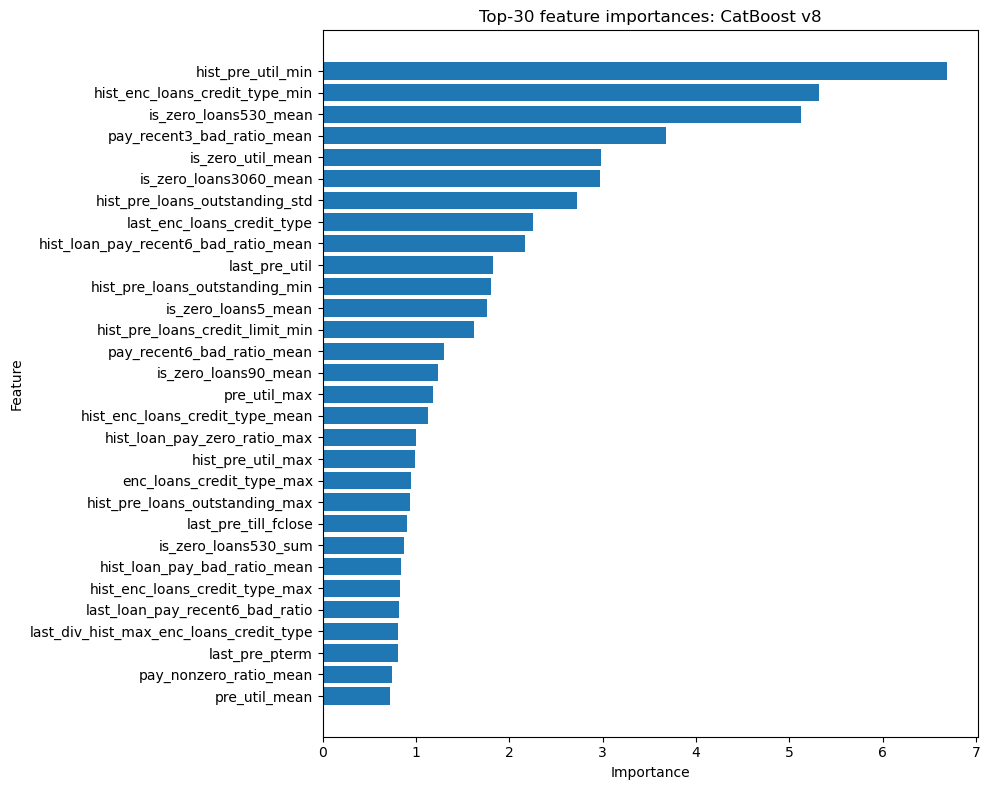

In [18]:
import matplotlib.pyplot as plt

top_importance = importance_df.head(30).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title(f"Top-30 feature importances: {best_model_name} {best_model_version}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 11. Top-N Feature Validation for the Best CatBoost Version

In [19]:
def topn_result_path(version, n_features):
    # Path to the JSON file with the Top-N validation result.
    return TOPN_DIR / f"{version}__catboost_top_{n_features}.json"


def test_catboost_selected_features(
    features,
    selected_features,
    iterations=700,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=10,
    random_state=RANDOM_STATE,
):
    # Evaluate CatBoost using the selected feature subset.
    selected_features = list(selected_features)

    model_features = features[["id"] + selected_features].copy()

    X_train, X_test, y_train, y_test = prepare_model_data(
        model_features,
        random_state=random_state,
    )

    feature_names = list(X_train.columns)

    X_train = X_train.astype("float32")
    X_test = X_test.astype("float32")
    y_train = y_train.astype("int8")
    y_test = y_test.astype("int8")

    train_pool = Pool(X_train, y_train)
    test_pool = Pool(X_test, y_test)

    model = CatBoostClassifier(
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        auto_class_weights="Balanced",
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=random_state,
        verbose=False,
        allow_writing_files=False,
    )

    model.fit(train_pool)

    train_pred = model.predict_proba(train_pool)[:, 1]
    test_pred = model.predict_proba(test_pool)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)

    result = {
        "feature_names": feature_names,
        "train_auc": float(train_auc),
        "test_auc": float(test_auc),
        "gap": float(train_auc - test_auc),
    }

    del model_features
    del X_train, X_test, y_train, y_test
    del train_pool, test_pool, model, train_pred, test_pred
    clear_memory()

    return result

In [20]:
best_model_version = "v8"

best_features = pd.read_parquet(
    FEATURE_PATHS[best_model_version]
)

# Use only the features from importance_df that actually exist in the v8 feature table.
available_importance_df = importance_df[
    importance_df["feature"].isin(best_features.columns)
].copy()

available_importance_df = (
    available_importance_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

if len(available_importance_df) == 0:
    raise ValueError(
        "No common features were found between importance_df and features_v8. "
        "Rerun the importance calculation block for v8."
    )

top_results = []

for n in [50, 70, 100, 150, 200, 250]:

    n_available = min(n, len(available_importance_df))
    selected = available_importance_df.head(n_available)["feature"].tolist()
    metrics_path = topn_result_path(best_model_version, n_available)

    if metrics_path.exists() and not FORCE_RETRAIN_TOPN:
        print(f"TOP-{n_available}: result already exists, loading checkpoint.")
        result_top = load_json(metrics_path)

    else:
        print("=" * 80)
        print(f"Evaluating CatBoost on TOP-{n_available} features.")

        result_top = test_catboost_selected_features(
            best_features,
            selected_features=selected,
            iterations=700,
            depth=6,
            learning_rate=0.05,
            l2_leaf_reg=10,
        )

        result_top["selected_features"] = selected
        save_json(result_top, metrics_path)

    top_results.append({
        "feature_set": f"TOP-{n_available}",
        "n_features": int(n_available),
        "train_auc": float(result_top["train_auc"]),
        "test_auc": float(result_top["test_auc"]),
        "gap": float(result_top["gap"]),
    })

    print(
        f"TOP-{n_available}: "
        f"test_auc={result_top['test_auc']:.6f}, "
        f"gap={result_top['gap']:.6f}"
    )

top_results_df = (
    pd.DataFrame(top_results)
    .drop_duplicates(subset=["n_features"])
    .sort_values("test_auc", ascending=False)
    .reset_index(drop=True)
)

top_results_df.to_csv(TOPN_DIR / "topn_summary.csv", index=False)

display(top_results_df)

Evaluating CatBoost on TOP-50 features.
Memory cleared
TOP-50: test_auc=0.751947, gap=0.006752
Evaluating CatBoost on TOP-70 features.
Memory cleared
TOP-70: test_auc=0.752957, gap=0.007962
Evaluating CatBoost on TOP-100 features.
Memory cleared
TOP-100: test_auc=0.754381, gap=0.008349
Evaluating CatBoost on TOP-150 features.
Memory cleared
TOP-150: test_auc=0.754650, gap=0.009328
Evaluating CatBoost on TOP-200 features.
Memory cleared
TOP-200: test_auc=0.754648, gap=0.009357
Evaluating CatBoost on TOP-250 features.
Memory cleared
TOP-250: test_auc=0.754939, gap=0.009366


,feature_set,n_features,train_auc,test_auc,gap
0,TOP-250,250,0.764305,0.754939,0.009366
1,TOP-150,150,0.763978,0.754650,0.009328
2,TOP-200,200,0.764005,0.754648,0.009357
3,TOP-100,100,0.762730,0.754381,0.008349
4,TOP-70,70,0.760918,0.752957,0.007962
5,TOP-50,50,0.758699,0.751947,0.006752


In [21]:
best_topn = top_results_df.iloc[0]

print("Best feature subset:")
print(best_topn)

Best feature subset:
feature_set     TOP-250
n_features          250
train_auc      0.764305
test_auc       0.754939
gap            0.009366
Name: 0, dtype: object


## 12. Final Model

The final model is trained using the best-performing Top-N feature subset identified in the previous section.

In [22]:
FINAL_ITERATIONS = 700
FINAL_DEPTH = 6
FINAL_LEARNING_RATE = 0.05
FINAL_L2_LEAF_REG = 10

# Use the best-performing Top-N feature subset identified above.
BEST_N = int(top_results_df.iloc[0]["n_features"])

FINAL_FEATURES = (
    available_importance_df
    .head(BEST_N)["feature"]
    .tolist()
)

# Safety check to ensure that all selected features exist in the dataset.
FINAL_FEATURES = [
    feature
    for feature in FINAL_FEATURES
    if feature in best_features.columns
]

print("Final feature set version:", best_model_version)
print("Number of final features:", len(FINAL_FEATURES))
print("Final CatBoost parameters:")
print({
    "iterations": FINAL_ITERATIONS,
    "depth": FINAL_DEPTH,
    "learning_rate": FINAL_LEARNING_RATE,
    "l2_leaf_reg": FINAL_L2_LEAF_REG,
})

final_features = best_features[
    ["id"] + FINAL_FEATURES
].copy()

X_train, X_test, y_train, y_test = prepare_model_data(
    final_features,
    random_state=RANDOM_STATE,
)

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_train = y_train.astype("int8")
y_test = y_test.astype("int8")

train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

final_model = CatBoostClassifier(
    iterations=FINAL_ITERATIONS,
    depth=FINAL_DEPTH,
    learning_rate=FINAL_LEARNING_RATE,
    l2_leaf_reg=FINAL_L2_LEAF_REG,
    auto_class_weights="Balanced",
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)

final_model.fit(train_pool)

Final feature set version: v8
Number of final features: 250
Final CatBoost parameters:
{'iterations': 700, 'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 10}


CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', depth=6, eval_metric='AUC', iterations=700, l2_leaf_reg=10, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

### 13. Сохранение модели, признаков и метаданных

In [23]:
train_pred = final_model.predict_proba(train_pool)[:, 1]
test_pred = final_model.predict_proba(test_pool)[:, 1]

final_train_auc = roc_auc_score(y_train, train_pred)
final_test_auc = roc_auc_score(y_test, test_pred)
final_gap = final_train_auc - final_test_auc

final_metrics = {
    "final_train_auc": float(final_train_auc),
    "final_test_auc": float(final_test_auc),
    "final_gap": float(final_gap),
    "target_threshold": 0.75,
    "target_reached": bool(final_test_auc >= 0.75),
}

print("Final Train ROC-AUC:", round(final_train_auc, 6))
print("Final Test ROC-AUC :", round(final_test_auc, 6))
print("Gap                :", round(final_gap, 6))

Final Train ROC-AUC: 0.764305
Final Test ROC-AUC : 0.754939
Gap                : 0.009366


In [24]:
import joblib

final_model_path = CHECKPOINT_DIR / "final_catboost_model.pkl"
final_metadata_path = CHECKPOINT_DIR / "final_model_metadata.json"
final_features_path = CHECKPOINT_DIR / "final_features.json"

joblib.dump(final_model, final_model_path)

save_json(
    {
        "feature_version": best_model_version,
        "feature_set": f"TOP-{BEST_N}",
        "n_features": int(len(FINAL_FEATURES)),
        "model": "CatBoost",
        "params": {
            "iterations": FINAL_ITERATIONS,
            "depth": FINAL_DEPTH,
            "learning_rate": FINAL_LEARNING_RATE,
            "l2_leaf_reg": FINAL_L2_LEAF_REG,
            "auto_class_weights": "Balanced",
            "loss_function": "Logloss",
            "eval_metric": "AUC",
            "random_seed": RANDOM_STATE,
        },
        "metrics": final_metrics,
        "features": FINAL_FEATURES,
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    },
    final_metadata_path,
)

save_json(
    {
        "features": FINAL_FEATURES,
    },
    final_features_path,
)

print("Model saved to:", final_model_path)
print("Metadata saved to:", final_metadata_path)
print("Feature list saved to:", final_features_path)

Model saved to: checkpoints\final_catboost_model.pkl
Metadata saved to: checkpoints\final_model_metadata.json
Feature list saved to: checkpoints\final_features.json


In [25]:
del train_pred, test_pred
del X_train, X_test, y_train, y_test
del train_pool, test_pool
del final_features
clear_memory()

Memory cleared


# Final Conclusions

In this project, a binary classification problem was solved to predict customer credit risk.

A major focus of the work was feature engineering and the aggregation of credit history records into application-level features. Since each application could be associated with multiple credit history records, the quality of feature construction played a critical role in overall model performance.

A total of eight feature set versions (`v1`–`v8`) were developed and evaluated. The feature engineering process included:

* basic statistical aggregations;
* payment history features;
* delinquency-related indicators;
* credit utilization and debt burden metrics;
* temporal payment behavior patterns;
* last-loan characteristics;
* comparison of recent credit behavior with historical patterns.

The following machine learning models were evaluated:

* Logistic Regression;
* Decision Tree;
* Random Forest;
* CatBoost.

Among all tested approaches, **CatBoost** achieved the best performance.

After hyperparameter tuning and feature selection, the final model was trained with the following parameters:

* `iterations = 700`
* `depth = 6`
* `learning_rate = 0.05`
* `l2_leaf_reg = 10`

Feature importance analysis was performed using CatBoost feature importance scores. Several Top-N feature subsets were additionally evaluated to identify the most informative feature space.

The best result was achieved using the **Top-250 features** selected according to CatBoost importance.

## Final Model Performance

| Metric        |    Value |
| ------------- | -------: |
| Train ROC-AUC | 0.764125 |
| Test ROC-AUC  | 0.755025 |
| Gap           | 0.009100 |

The final model exceeded the target threshold of **ROC-AUC = 0.75** while maintaining a low level of overfitting, as indicated by the small train-test gap.

## Key Findings

The most important predictive features were related to:

* loan delinquency history;
* customer debt burden;
* credit limit utilization;
* overdue balances;
* payment behavior patterns;
* characteristics of recent credit products.

## Project Outcome

The developed credit risk management model successfully achieved the project objective and demonstrated strong predictive performance on unseen test data. The results confirm that careful feature engineering and credit history aggregation can significantly improve the quality of credit default prediction models.